   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (200, 5)


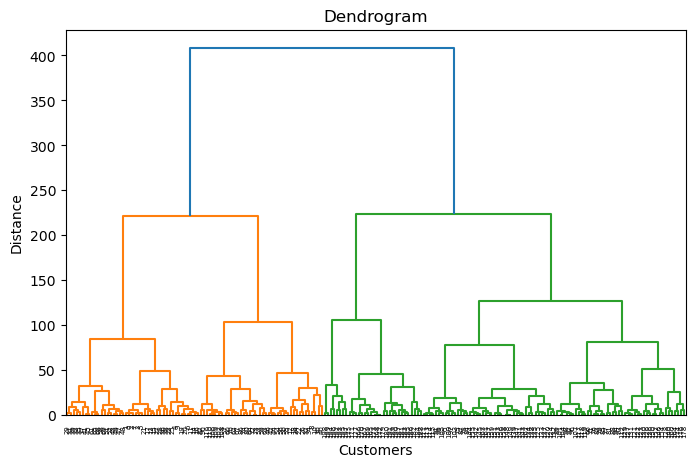


Clustered Data:
    CustomerID  Age  Annual Income (k$)  Cluster
0            1   19                  15        3
1            2   21                  15        3
2            3   20                  16        3
3            4   23                  16        3
4            5   31                  17        3
5            6   22                  17        3
6            7   35                  18        3
7            8   23                  18        3
8            9   64                  19        1
9           10   30                  19        3
10          11   67                  19        1
11          12   35                  19        3
12          13   58                  20        1
13          14   24                  20        3
14          15   37                  20        3
15          16   22                  20        3
16          17   35                  21        3
17          18   20                  21        3
18          19   52                  23        1
19 

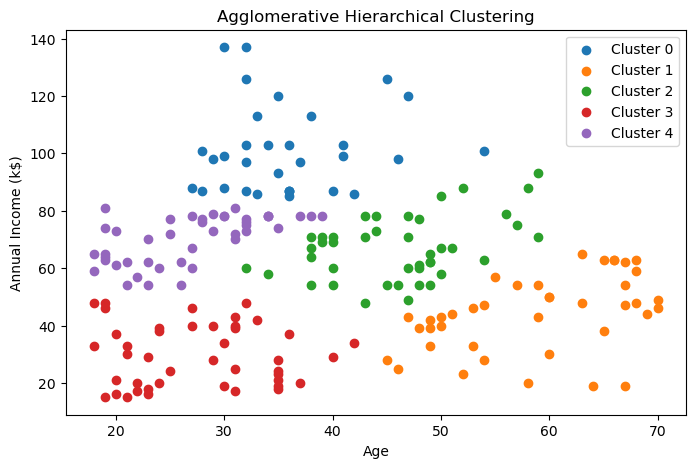

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load dataset
df = pd.read_csv("Mall_Customers.csv")

# 2. Explore dataset
print(df.head())
print("\nDataset Shape:", df.shape)

# 3. Select features
X = df[["Age", "Annual Income (k$)"]]

# 4. Create dendrogram
plt.figure(figsize=(8, 5))
link = linkage(X, method="ward")

dendrogram(link)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# 5. Apply Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

df["Cluster"] = model.fit_predict(X)

# 6. Display clusters
print("\nClustered Data:")
print(df[["CustomerID", "Age", "Annual Income (k$)", "Cluster"]].head(20))

# 7. Visualize clusters
plt.figure(figsize=(8, 5))

for cluster in range(5):
    data = df[df["Cluster"] == cluster]
    plt.scatter(
        data["Age"],
        data["Annual Income (k$)"],
        label="Cluster " + str(cluster)
    )

plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.title("Agglomerative Hierarchical Clustering")
plt.legend()
plt.show()